Loading Datasets...
✅ Detected 8 classes: ['AMD', 'CNV', 'CSR', 'DME', 'DR', 'DRUSEN', 'MH', 'NORMAL']
Found 12000 files belonging to 8 classes.
Found 12600 files belonging to 8 classes.
Model: "Retinal_8_Class_Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 random_flip_1 (RandomFlip)  (None, 224, 224, 3)       0         
                                                                 
 random_rotation_1 (RandomRo  (None, 224, 224, 3)      0         
 tation)                                                         
                                                                 
 MobilenetV3large (Functiona  (None, 7, 7, 960)        2996352   
 l)                                                              
                                                        

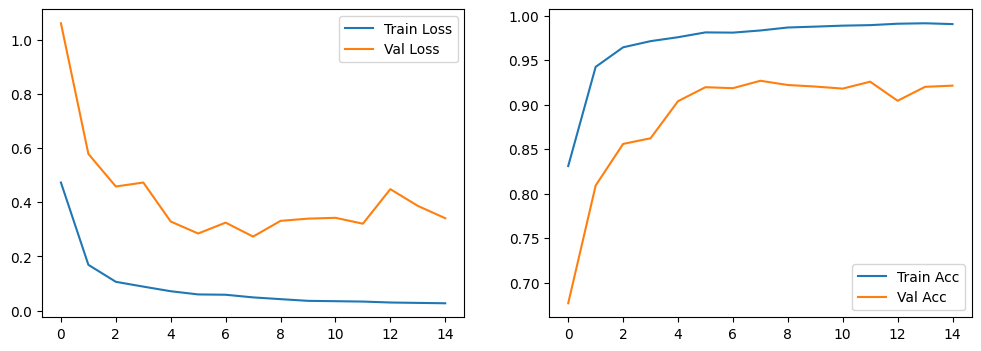

In [4]:
import os
import pickle
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow_addons as tfa 
from tensorflow.keras.utils import image_dataset_from_directory

# --- 1. CONFIGURATION ---
BATCH_SIZE = 16
IMG_SIZE = (224, 224)
EPOCHS = 15
LEARNING_RATE = 1e-4

# --- 2. DATA LOADING ---
train_dir = 'train'
val_dir = 'val'

print("Loading Datasets...")
# AUTO-DETECT 8 CLASSES
if os.path.exists(train_dir):
    class_names = sorted(os.listdir(train_dir))
    NUM_CLASSES = len(class_names)
    print(f"✅ Detected {NUM_CLASSES} classes: {class_names}")
    # Expected: ['amd', 'cnv', 'csr', 'dme', 'dr', 'drusen', 'mh', 'normal']
else:
    raise FileNotFoundError(f"Directory '{train_dir}' not found.")

train_ds = image_dataset_from_directory(
    train_dir,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_ds = image_dataset_from_directory(
    val_dir,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# --- 3. MODEL ARCHITECTURE ---
base_model = tf.keras.applications.MobileNetV3Large(
    input_shape=IMG_SIZE + (3,),
    include_top=False, 
    weights='imagenet'
)
base_model.trainable = True 

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = tf.keras.layers.RandomFlip("horizontal")(inputs)
x = tf.keras.layers.RandomRotation(0.1)(x)
x = tf.keras.applications.mobilenet_v3.preprocess_input(x)
x = base_model(x)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)

# Output layer now adapts to NUM_CLASSES (8)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name="Retinal_8_Class_Model")

# --- 4. TRAINING ---
metrics_list = ['accuracy', tfa.metrics.F1Score(num_classes=NUM_CLASSES, average='macro')]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=metrics_list
)

model.summary()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# --- 5. SAVING ---
model.save("Trained_Model.keras") 
with open('Training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

# Visualize
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.show()